In [25]:
import tifffile as tiff
from tifffile import imwrite
import platform
system = platform.system()
import numpy as np
import matplotlib.pyplot as plt


import os
from skimage.filters import try_all_threshold, threshold_otsu,  threshold_triangle, threshold_yen, threshold_li


if system == 'Linux':
    home = '/home/'
elif system == 'Darwin':
    home = '/Users/'



In [26]:
def fast_threshold_li(stack):
    s_min, s_max = float(stack.min()), float(stack.max())
    if s_max == s_min:
        return s_min
    u16 = ((stack - s_min) / (s_max - s_min) * 65535).astype(np.uint16)
    t_u16 = threshold_li(u16)
    return t_u16 / 65535 * (s_max - s_min) + s_min

Processing series 1---------------
Processing channel 0************************
treshold = 31
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_masks_triangle.tif


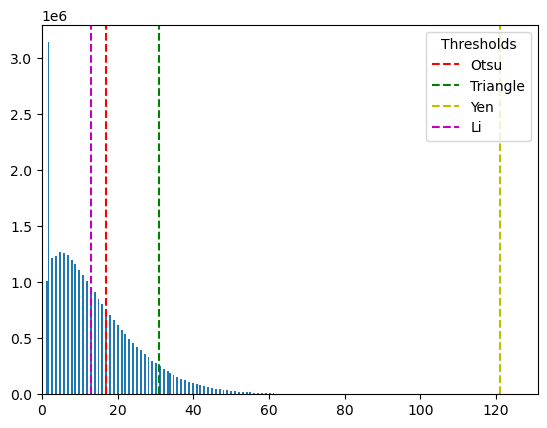

/home/gerard/miniconda3/envs/leica-env/lib/python3.11/site-packages/skimage/filters/thresholding.py:440: RuntimeWarning: divide by zero encountered in log
  crit = np.log(((P1_sq[:-1] * P2_sq[1:]) ** -1) *


treshold = 29.156204223632812
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_deconv_iter_4_masks_triangle.tif


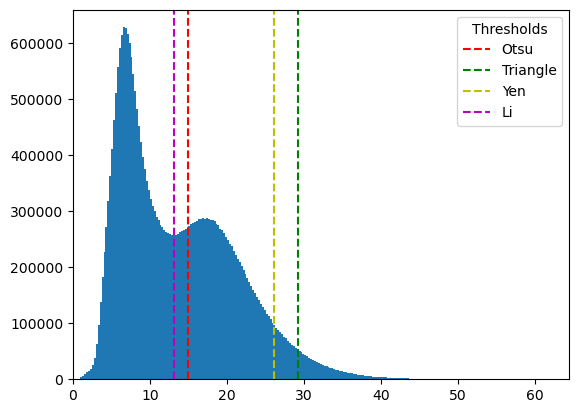

Processing channel 1************************
treshold = 3
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_masks_triangle.tif


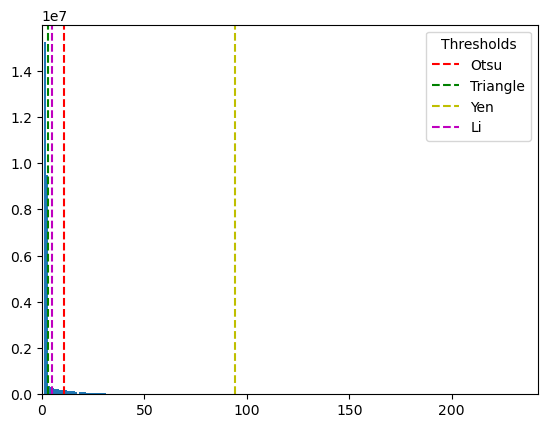

treshold = 4.988361358642578
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_deconv_iter_4_masks_triangle.tif


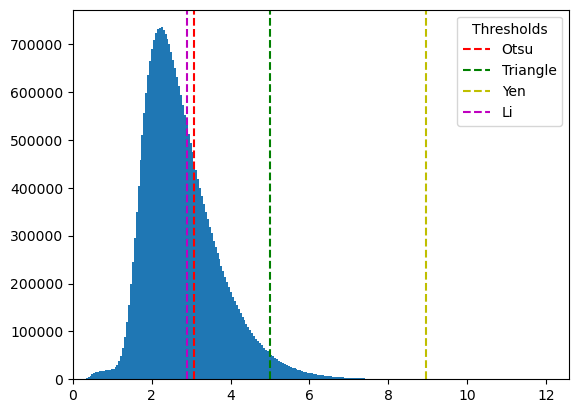

Processing channel 2************************
treshold = 17
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_2/2026_05_26_s1_ch2_masks_triangle.tif


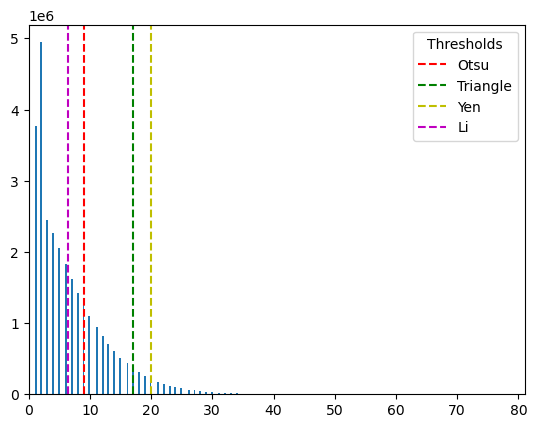

treshold = 12.91905403137207
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_2/2026_05_26_s1_ch2_deconv_iter_4_masks_triangle.tif


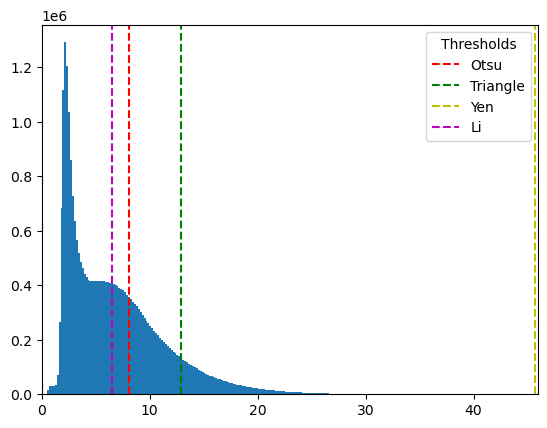

In [28]:
treshold_algorithm_list =[
    'triangle',
   # 'otsu',
]

series_list = [
  #  0,
    1,
   # 2,
    
]


channel_list = [
   0,
   1,
   2,
    
]
deconv_iter_list = [
    # 1,
    # 2,
    # 3,
   4,
    # 5,
    # 6,
    # 7,
    

]

stack_list = []
mask_list = []
stack_list_deconv = []
mask_list_deconv = []

for series in series_list:
    print(f'Processing series {series}---------------')
    for channel in channel_list:
        print(f'Processing channel {channel}************************')
        for deconv_inter in deconv_iter_list:
        
            path_series_channel = f'gerard/data/confocal/2026_05_26_Gerardo/series_{series}/channel_{channel}'#gerard/data/confocal/2026_05_26_Gerardo/Project.lif'
            base = home + path_series_channel #os.path.join(home, )
            

            path_raw        = os.path.join(base, f'2026_05_26_s{series}_ch{channel}.tif')
            path_raw_masks  = os.path.join(base, f'2026_05_26_s{series}_ch{channel}_masks')
            path_deconv      = os.path.join(base, f'2026_05_26_s{series}_ch{channel}_deconv_iter_{deconv_inter}.tif')
            path_deconv_masks= os.path.join(base, f'2026_05_26_s{series}_ch{channel}_deconv_iter_{deconv_inter}_masks')

            for path_in, path_out in [(path_raw, path_raw_masks), (path_deconv, path_deconv_masks)]:
                
                with tiff.TiffFile(path_in) as tf:
                    stack = tf.asarray()
                    vxy = 1.0 / (tf.pages[0].tags['XResolution'].value[0] / tf.pages[0].tags['XResolution'].value[1])
                    vz  = tf.imagej_metadata['spacing']

                
                
                for treshold_algorithm in treshold_algorithm_list:
                    if treshold_algorithm == 'triangle':
                        thresh = threshold_triangle(stack)
                    elif treshold_algorithm == 'otsu':
                        thresh = threshold_otsu(stack)

                    # calculate several thresholds to plot:
                    stack_flat = stack[stack > 0]
                    otsu = threshold_otsu(stack)
                    triangle = threshold_triangle(stack)
                    yen = threshold_yen(stack)
                    #li = threshold_li(stack)
                    li = fast_threshold_li(stack)   # fast, same histogram shape

                    # pct_90 = np.percentile(stack_flat, 90)
                    # pct_95 = np.percentile(stack_flat, 95)
                    
                    
                    
                    print(f'treshold = {thresh}')
                
                    masks  = (stack > thresh).astype(np.uint8)
                    # for frame in range(masks.shape[0]):
                    #     print(np.max(masks[frame]))
                    
                    if 'deconv' in path_in:
                        stack_list_deconv.append(stack)
                        mask_list_deconv.append(masks)
                    else:
                        stack_list.append(stack)
                        mask_list.append(masks)
                    

                    path_out_al = path_out + '_' + treshold_algorithm + '.tif'
                    imwrite(path_out_al, masks, imagej=True, resolution=(1/vxy, 1/vxy),
                            metadata={'spacing': vz, 'unit': 'um', 'axes': 'ZYX'})
                    
                    print(f'saved {path_out_al}')
                    
                    plt.figure()
                    plt.hist(stack.ravel(), bins=256)
                    
                    plt.axvline(otsu, color='r', linestyle='--', label='Otsu')
                    
                    plt.axvline(triangle, color='g', linestyle='--', label='Triangle')
                    plt.axvline(yen, color='y', linestyle='--', label='Yen')
                    plt.axvline(li, color='m', linestyle='--', label='Li')
                    
                    plt.legend(loc='upper right', title='Thresholds')

                    # plt.axvline(pct_90, color='c', linestyle='--')
                    # plt.axvline(pct_95, color='m', linestyle='--')
                    
                    vmin, vmax = np.percentile(stack.ravel(), [1, 100])
                    plt.xlim(0,vmax)# stack.max())
                    plt.show()

                    
                    
                
                # stack_flat = stack[stack > 0]
                # print(f'file:{path_in}\n series:{series}, channel:{channel}, deconv iter: {deconv_inter}')
                # print(f"Otsu:       {threshold_otsu(stack):.1f}")
                # print(f"Triangle:   {threshold_triangle(stack):.1f}")
                # print(f"Yen:        {threshold_yen(stack):.1f}")
                # print(f"90th pct:   {np.percentile(stack_flat, 90):.1f}")
                # print(f"95th pct:   {np.percentile(stack_flat, 95):.1f}")



In [31]:
print(len(stack_list), len(mask_list), len(stack_list_deconv), len(mask_list_deconv))

3 3 3 3


In [45]:
ch0 = stack_list_deconv[0] #
ch1 = stack_list_deconv[1] #
ch2 = stack_list_deconv[2] #

mask_ch0 = mask_list_deconv[0]
mask_ch1 = mask_list_deconv[1]
mask_ch2 = mask_list_deconv[2]

mask = (mask_ch1 | mask_ch2).astype(bool)

# series 1, channel 0, deconv iter 4
r_per_frame = []
for z in range(ch1.shape[0]):
    ch1_f, ch2_f, mask_f = ch1[z], ch2[z], mask[z]
    print(mask_f.sum())
    if mask_f.sum() < 500:  # skip nearly empty frames
        r_per_frame.append(np.nan)
        continue
    r = np.corrcoef(ch1_f[mask_f], ch2_f[mask_f])[0, 1]
    r_per_frame.append(r)


0
65
37
31
62
199
188
116
165
98
100
338
629
944
1072
997
1363
2012
3708
4576
5800
6932
7989
8385
8133
8149
8009
7920
7706
7029
6383
5125
4317
3149
3054
2601
2838
2567
3268
4251
5960
7331
8556
10093
14206
17496
22247
25489
29063
32793
38598
40108
45642
51408
55810
61331
62293
65314
69636
74573
76385
82285
84968
89349
87629
84696
84032
80164
79389
79329
79123
81167
82934
85376
89006
90505
92281
91924
93301
91000
88845
81770
75001
66564
56608
45536
34140
24108
16004
10613
8296
5348
3626
2655
1697
1386
2220
1102
745
773
853
810
1053
1775
2392
2022
1618
636
65
13


[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 0.04661692156820857, -0.42989308640427004, -0.09406381629515467, 0.2307641319874639, 0.05562939856945408, 0.027023981865967727, 0.07366518565522384, 0.03458888300738708, 0.3627964163798536, 0.17667821562421243, 0.27608042297768814, 0.19550304791021955, 0.4135982191275371, 0.3082074593702331, 0.035070411753972734, 0.21203577452938177, 0.026741414174281455, -0.142258968019589, -0.18007197853437296, -0.07871306633475858, -0.06636207694977997, 0.2724873855010181, -0.3611836103171422, -0.5198571915825221, -0.5062964522429986, -0.4900031083952264, -0.6586675676957321, -0.5730372393175729, -0.47154741110282494, -0.3676207133745031, -0.17210083823182948, -0.15631169540140258, -0.30195104618629437, -0.17917036949548665, -0.2146950315095029, -0.07024068367366587, -0.10994611184723352, -0.03209310169434071, -0.07000093989328741, 0.007592746480969304, -0.01310041850574773, 0.00877055559446665, -0.020584550698538772, 0.01897719096811742, 

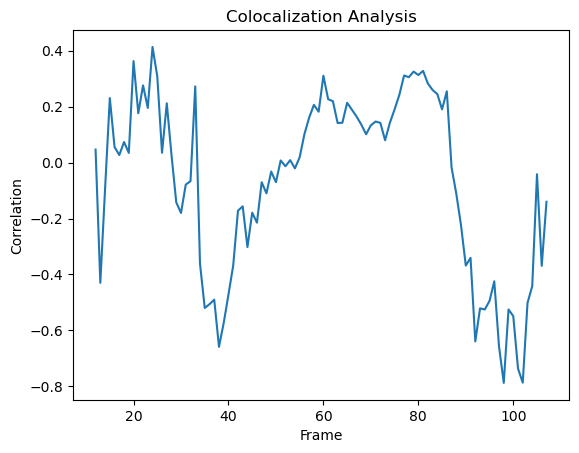

In [47]:
print(r_per_frame)

plt.figure()
plt.plot(r_per_frame)
plt.xlabel('Frame')
plt.ylabel('Correlation')
plt.title('Colocalization Analysis')
plt.show()